<a href="https://colab.research.google.com/github/vkantimahanti/healthcare-ml-portfolio/blob/main/breast_cancer_randomforest_xgboost_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports + switch to classification dataset

In [1]:
!pip install mlflow shap -q

'''
mlflow - Installs MLflow, an open-source platform used to manage the machine learning lifecycle, including experiment tracking, model packaging, and deployment.
shap - Installs SHAP (SHapley Additive exPlanations), a library used for "model explainability." it helps you understand how different features in your data contribute to a model's specific predictions.
-q -  A flag that tells pip to be "quiet." It hides non-error messages (like progress bars and successful download notifications) to keep your terminal or notebook output clean.
'''

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.5/829.5 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 7.3 MB/s eta 0:00:00


'\nmlflow - Installs MLflow, an open-source platform used to manage the machine learning lifecycle, including experiment tracking, model packaging, and deployment.\nshap - Installs SHAP (SHapley Additive exPlanations), a library used for "model explainability." it helps you understand how different features in your data contribute to a model\'s specific predictions.\n-q -  A flag that tells pip to be "quiet." It hides non-error messages (like progress bars and successful download notifications) to keep your terminal or notebook output clean.\n'

In [2]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
import warnings
warnings.filterwarnings('ignore')

In [15]:


# Switch to CLASSIFICATION today — predict cancer yes/no
# Breast cancer dataset: 569 patients, 30 clinical features
# Target: malignant (1) or benign (0)
data  = load_breast_cancer()
X     = pd.DataFrame(data.data, columns=data.feature_names)
y     = pd.Series(data.target, name='cancer')

# Check class balance — critical in healthcare
print(f"Dataset shape : {X.shape}")
print(f"Malignant (1) : {(y==1).sum()} patients ({(y==1).mean()*100:.1f}%)")
print(f"Benign    (0) : {(y==0).sum()} patients ({(y==0).mean()*100:.1f}%)")
print(f"\nIf we predict everyone benign — accuracy would be: {(y==0).mean()*100:.1f}%")
print("That's why accuracy alone is misleading ↑")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

Dataset shape : (569, 30)
Malignant (1) : 357 patients (62.7%)
Benign    (0) : 212 patients (37.3%)

If we predict everyone benign — accuracy would be: 37.3%
That's why accuracy alone is misleading ↑

Train: (455, 30) | Test: (114, 30)


Build pipeline + print all metrics

In [17]:
# Build pipeline using Wednesday's pattern
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
    ('model',   RandomForestClassifier(
                    n_estimators=100,
                    max_depth=5,
                    random_state=42,
                    class_weight='balanced'  # handles class imbalance -- This is the most important setting here. In healthcare, you often have many healthy patients and only a few sick ones. This setting tells the model to pay extra attention to the sick patients so they don't get "drowned out" by the healthy majority.
                ))
])

pipeline.fit(X_train, y_train)
y_pred      = pipeline.predict(X_test)
y_pred_prob = pipeline.predict_proba(X_test)[:, 1] # The "Confidence" Score
'''
y_pred_prob:
This is the most important part for doctors. Instead of just a "Yes" or "No," this gives you the probability.
What it does: It asks the model, "How sure are you?"
The [:, 1] part: The model outputs two numbers (e.g., 10% chance of 0, 90% chance of 1). This code snippet grabs only the second number—the probability that the patient is in Class 1 (Benign).
Why it matters: In medicine, a "Yes" with 51% certainty is very different from a "Yes" with 99% certainty. This score lets you see that difference.
'''

# All metrics in one place
accuracy  = accuracy_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print("=" * 45)
print("  Metric          Score    Healthcare meaning")
print("=" * 45)
print(f"  Accuracy      : {accuracy:.3f}  → misleading on imbalanced data")
print(f"  Recall        : {recall:.3f}  → % sick patients correctly caught")
print(f"  Precision     : {precision:.3f}  → % flagged patients actually sick")
print(f"  F1 Score      : {f1:.3f}  → balance of recall + precision")
print(f"  ROC-AUC       : {roc_auc:.3f}  → overall separation ability")
print("=" * 45)
print(f"\nPriority in healthcare: RECALL first → {recall:.3f}")

  Metric          Score    Healthcare meaning
  Accuracy      : 0.930  → misleading on imbalanced data
  Recall        : 0.931  → % sick patients correctly caught
  Precision     : 0.957  → % flagged patients actually sick
  F1 Score      : 0.944  → balance of recall + precision
  ROC-AUC       : 0.994  → overall separation ability

Priority in healthcare: RECALL first → 0.931


Confusion matrix — the most important visual

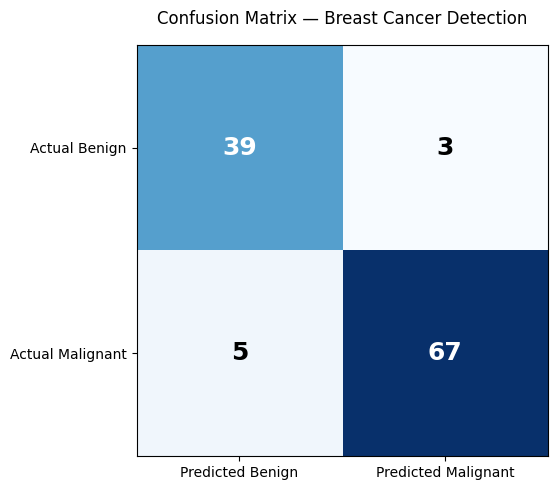

True Negative  (TN): 39  → correctly said benign  ✅
False Positive (FP): 3  → said malignant, actually benign  ⚠ unnecessary anxiety
False Negative (FN): 5  → said benign, actually malignant ❌ DANGEROUS — missed cancer
True Positive  (TP): 67  → correctly caught malignant  ✅

False Negatives (missed cancers): 5 — this is what recall minimises


In [19]:
# Confusion matrix breaks down exactly where the model fails
# This is what you show a doctor or clinical team

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted Benign', 'Predicted Malignant'])
ax.set_yticklabels(['Actual Benign', 'Actual Malignant'])
ax.set_title('Confusion Matrix — Breast Cancer Detection', pad=15)

# Add numbers inside boxes
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Explain each box in healthcare terms
tn, fp, fn, tp = cm.ravel()
print(f"True Negative  (TN): {tn}  → correctly said benign  ✅")
print(f"False Positive (FP): {fp}  → said malignant, actually benign  ⚠ unnecessary anxiety")
print(f"False Negative (FN): {fn}  → said benign, actually malignant ❌ DANGEROUS — missed cancer")
print(f"True Positive  (TP): {tp}  → correctly caught malignant  ✅")
print(f"\nFalse Negatives (missed cancers): {fn} — this is what recall minimises")

ROC curve — choosing the right threshold

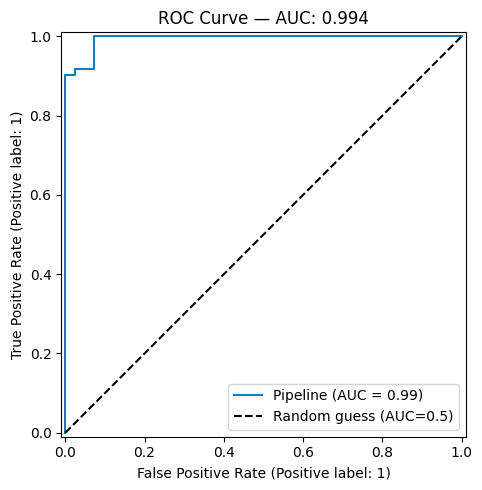

Threshold sensitivity — what changes when you lower threshold:
 Threshold   Recall  Precision     F1
----------------------------------------
       0.3    1.000      0.960  0.980
       0.4    0.986      0.959  0.973
       0.5    0.931      0.957  0.944 ← default
       0.6    0.917      0.957  0.936
       0.7    0.903      0.985  0.942

Lower threshold = higher recall = fewer missed cancers
Tradeoff: more false alarms (lower precision)


In [21]:
# ROC curve shows recall vs false alarm rate at every threshold
# Default threshold = 0.5 — but in healthcare you often lower it
# Lower threshold = catch more sick patients = higher recall
# Tradeoff: more false alarms (lower precision)

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax)
ax.plot([0,1], [0,1], 'k--', label='Random guess (AUC=0.5)')
ax.set_title(f'ROC Curve — AUC: {roc_auc:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# Show what happens when you lower the threshold
print("Threshold sensitivity — what changes when you lower threshold:")
print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} {'F1':>6}")
print("-" * 40)
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t   = (y_pred_prob >= threshold).astype(int)
    rec        = recall_score(y_test, y_pred_t)
    prec       = precision_score(y_test, y_pred_t, zero_division=0)
    f1_t       = f1_score(y_test, y_pred_t, zero_division=0)
    marker     = " ← default" if threshold == 0.5 else ""
    print(f"{threshold:>10.1f} {rec:>8.3f} {prec:>10.3f} {f1_t:>6.3f}{marker}")

print("\nLower threshold = higher recall = fewer missed cancers")
print("Tradeoff: more false alarms (lower precision)")

  Compare models on recall specifically

In [22]:
# In healthcare you compare models on RECALL — not accuracy
# Log everything to MLflow

models = {
    'Random Forest'     : RandomForestClassifier(n_estimators=100, max_depth=5,
                              random_state=42, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(max_iter=1000,
                              class_weight='balanced', random_state=42)
}

mlflow.set_experiment("breast-cancer-evaluation-metrics")

results = []
for name, mdl in models.items():
    pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  RobustScaler()),
        ('model',   mdl)
    ])
    pipe.fit(X_train, y_train)
    y_p      = pipe.predict(X_test)
    y_prob   = pipe.predict_proba(X_test)[:, 1]
    rec      = recall_score(y_test, y_p)
    prec     = precision_score(y_test, y_p)
    auc      = roc_auc_score(y_test, y_prob)
    f1_s     = f1_score(y_test, y_p)

    with mlflow.start_run(run_name=name.lower().replace(' ', '-')):
        mlflow.log_param("model",         name)
        mlflow.log_param("class_weight",  "balanced")
        mlflow.log_metric("recall",       round(rec, 3))
        mlflow.log_metric("precision",    round(prec, 3))
        mlflow.log_metric("roc_auc",      round(auc, 3))
        mlflow.log_metric("f1",           round(f1_s, 3))
        mlflow.sklearn.log_model(pipe, name.lower().replace(' ', '-'))

    results.append({'Model': name, 'Recall': round(rec,3),
                    'Precision': round(prec,3), 'ROC-AUC': round(auc,3),
                    'F1': round(f1_s,3)})
    print(f"✓ {name:22s} | Recall: {rec:.3f} | AUC: {auc:.3f}")

df = pd.DataFrame(results).sort_values('Recall', ascending=False)
print("\nFinal comparison — sorted by Recall (healthcare priority):")
print(df.to_string(index=False))

2026/03/15 19:08:52 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/15 19:08:52 INFO mlflow.store.db.utils: Updating database tables
2026/03/15 19:08:54 INFO mlflow.tracking.fluent: Experiment with name 'breast-cancer-evaluation-metrics' does not exist. Creating a new experiment.
2026/03/15 19:08:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 19:08:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓ Random Forest          | Recall: 0.931 | AUC: 0.994


2026/03/15 19:09:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 19:09:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓ Logistic Regression    | Recall: 0.944 | AUC: 0.996

Final comparison — sorted by Recall (healthcare priority):
              Model  Recall  Precision  ROC-AUC    F1
Logistic Regression   0.944      0.986    0.996 0.965
      Random Forest   0.931      0.957    0.994 0.944


In [23]:
import joblib

# Save best pipeline
joblib.dump(pipeline, 'breast_cancer_pipeline.pkl')

!git add .
!git commit -m "feat: day 4 - evaluation metrics, confusion matrix, ROC-AUC, recall focus"
!git push origin main
print("Pushed ✓ ")

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
Pushed ✓ 
